In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
features = pd.read_csv("features.csv")
train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")

In [4]:
train.head()
features.head()
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

In [7]:
df = train.merge(features, on=['Store','Date','IsHoliday'])
df = df.merge(stores, on='Store')

In [8]:
df.head()
df.shape

(421570, 16)

In [9]:
df.fillna(0, inplace=True)

In [10]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [16]:
sales_data = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

sales_data['Date'] = pd.to_datetime(sales_data['Date'])
sales_data = sales_data.set_index('Date')

# Set weekly frequency
sales_data = sales_data.asfreq('W-FRI')

sales_data.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


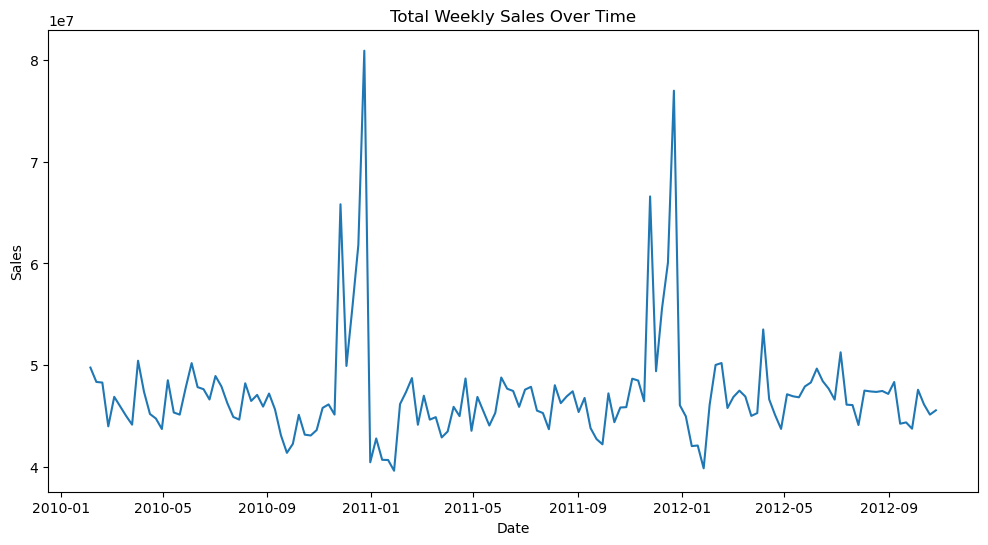

In [17]:
plt.figure(figsize=(12,6))
plt.plot(sales_data)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

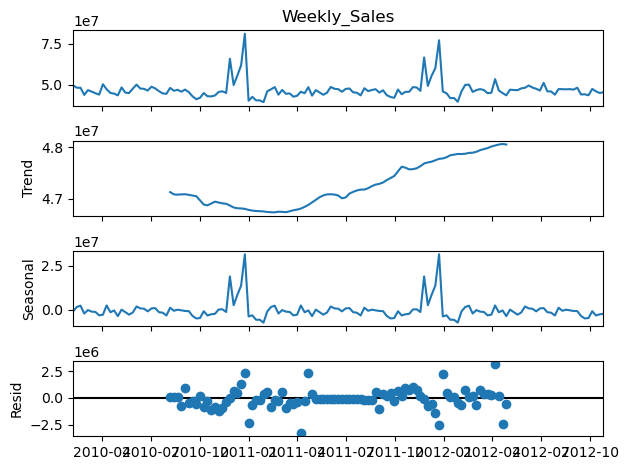

In [18]:
decomposition = seasonal_decompose(sales_data['Weekly_Sales'], model='additive', period=52)

decomposition.plot()
plt.show()

In [21]:
train_data = sales_data[:-20]
test_data = sales_data[-20:]

In [22]:
model = ARIMA(train_data['Weekly_Sales'], order=(5,1,0))
model_fit = model.fit()

In [24]:
forecast = forecast[:len(test_data)]

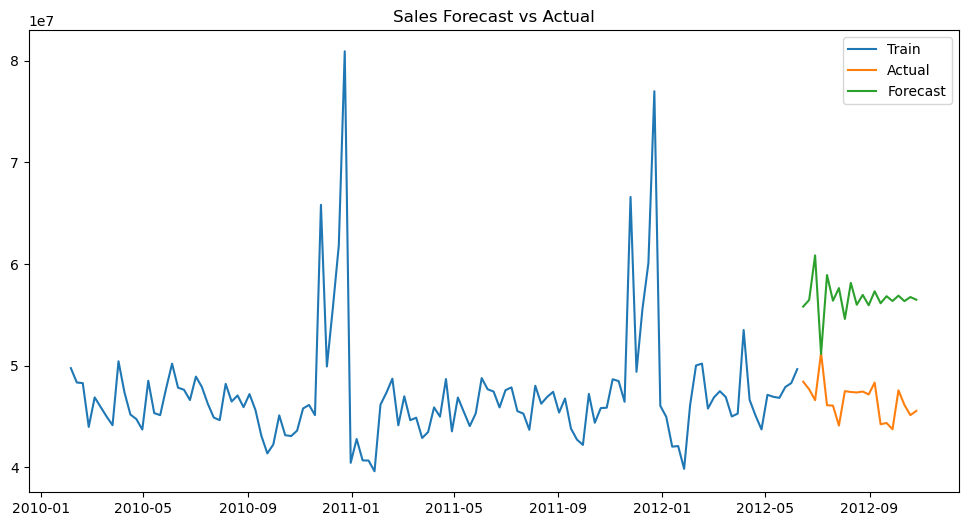

In [25]:
plt.figure(figsize=(12,6))

plt.plot(train_data.index, train_data['Weekly_Sales'], label="Train")
plt.plot(test_data.index, test_data['Weekly_Sales'], label="Actual")
plt.plot(test_data.index, forecast, label="Forecast")

plt.legend()
plt.title("Sales Forecast vs Actual")
plt.show()

In [26]:
forecast = pd.Series(forecast, index=test_data.index)

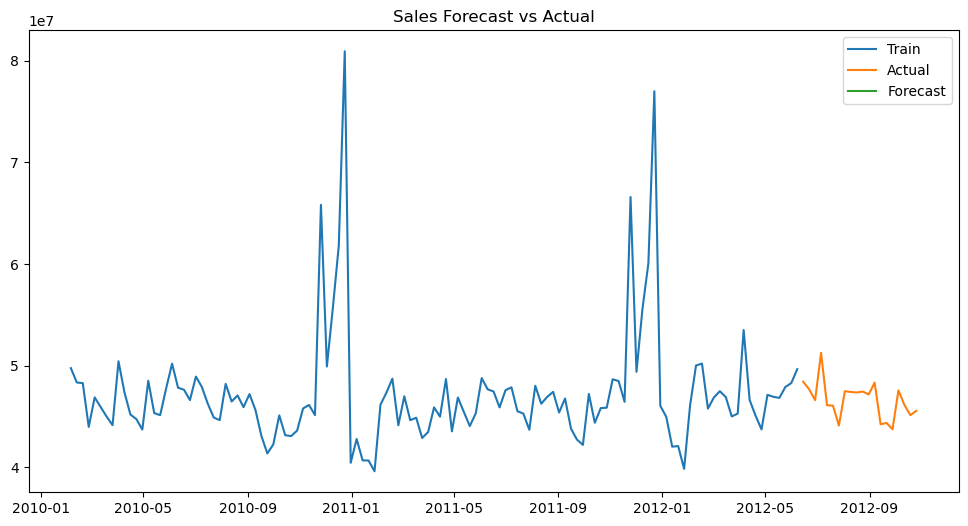

In [27]:
plt.figure(figsize=(12,6))

plt.plot(train_data['Weekly_Sales'], label="Train")
plt.plot(test_data['Weekly_Sales'], label="Actual")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("Sales Forecast vs Actual")
plt.show()

In [29]:
forecast.isna().sum()

20

In [30]:
model = ARIMA(train_data['Weekly_Sales'], order=(5,1,0))
model_fit = model.fit()

In [31]:
forecast = model_fit.forecast(steps=len(test_data))

In [32]:
forecast = pd.Series(forecast, index=test_data.index)

In [33]:
forecast.isna().sum()

0

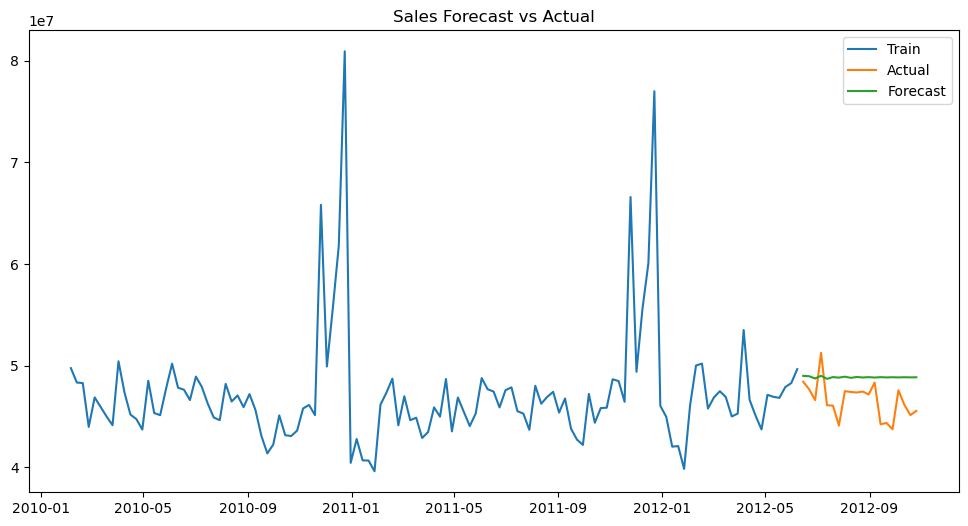

In [34]:
plt.figure(figsize=(12,6))

plt.plot(train_data['Weekly_Sales'], label="Train")
plt.plot(test_data['Weekly_Sales'], label="Actual")
plt.plot(forecast, label="Forecast")

plt.legend()
plt.title("Sales Forecast vs Actual")
plt.show()

In [35]:
mae = mean_absolute_error(test_data['Weekly_Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test_data['Weekly_Sales'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2477886.9859156776
RMSE: 2841487.3208183544


In [36]:
sales_data = df.groupby('Date')['Weekly_Sales'].sum()

In [37]:
mape = np.mean(np.abs((test_data['Weekly_Sales'] - forecast) / test_data['Weekly_Sales'])) * 100
print("MAPE:", mape)

MAPE: 5.419092724662479


In [38]:
df['Total_MarkDown'] = df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].sum(axis=1)

In [39]:
df[['Total_MarkDown','Weekly_Sales']].head()

,Total_MarkDown,Weekly_Sales
0,0.0,24924.50
1,0.0,46039.49
2,0.0,41595.55
3,0.0,19403.54
4,0.0,21827.90


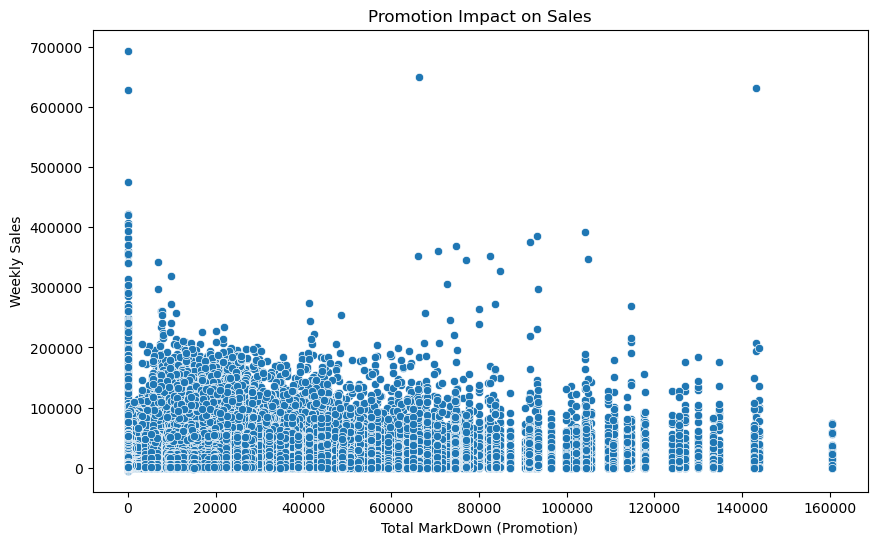

In [40]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Total_MarkDown'], y=df['Weekly_Sales'])

plt.title("Promotion Impact on Sales")
plt.xlabel("Total MarkDown (Promotion)")
plt.ylabel("Weekly Sales")
plt.show()

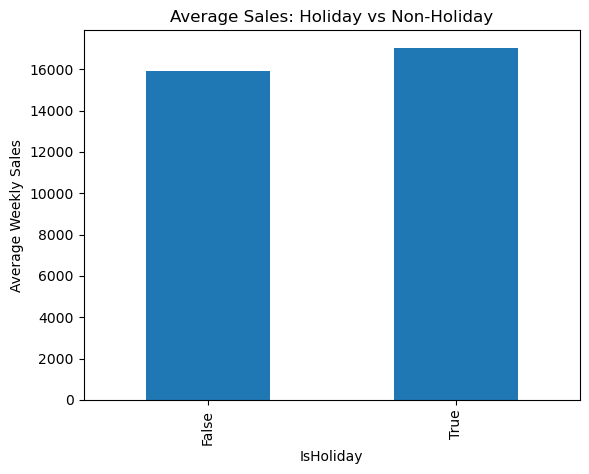

In [41]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales.plot(kind='bar')

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Weekly Sales")
plt.show()

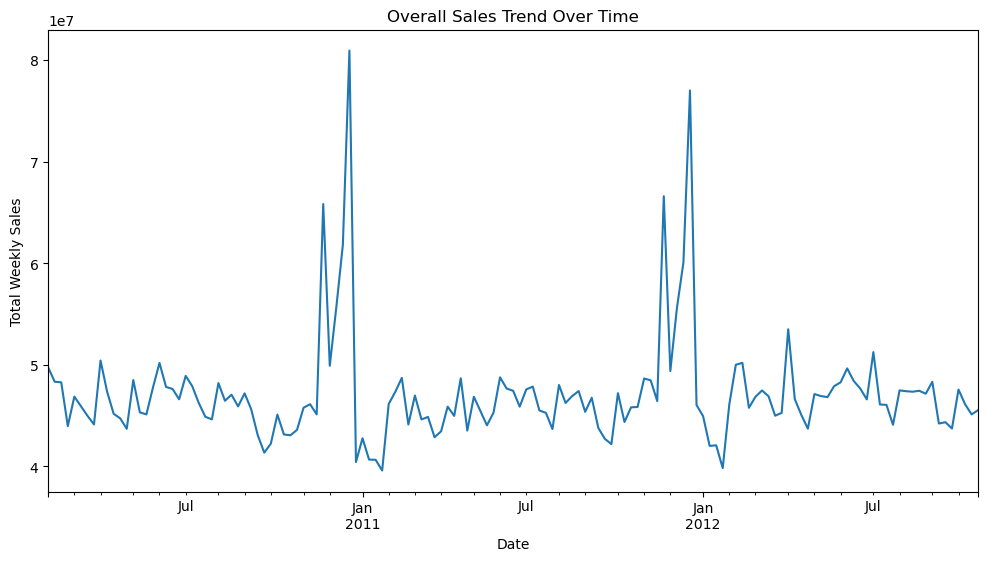

In [44]:
plt.figure(figsize=(12,6))
sales_data.plot()

plt.title("Overall Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.show()

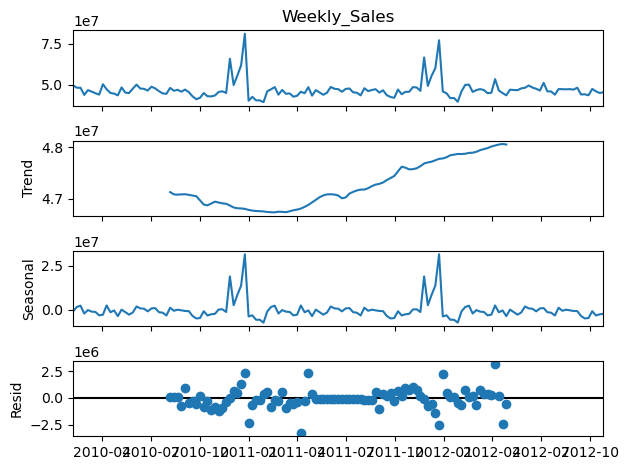

In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(sales_data, model='additive', period=52)

decomposition.plot()
plt.show()

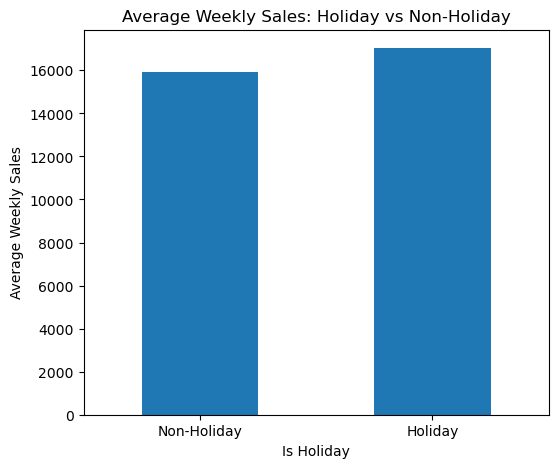

In [46]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(6,5))
holiday_sales.plot(kind='bar')

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Average Weekly Sales")
plt.xticks([0,1], ['Non-Holiday','Holiday'], rotation=0)

plt.show()

In [47]:
df['Total_MarkDown'] = df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].sum(axis=1)

In [48]:
df[['Total_MarkDown','Weekly_Sales']].head()

,Total_MarkDown,Weekly_Sales
0,0.0,24924.50
1,0.0,46039.49
2,0.0,41595.55
3,0.0,19403.54
4,0.0,21827.90


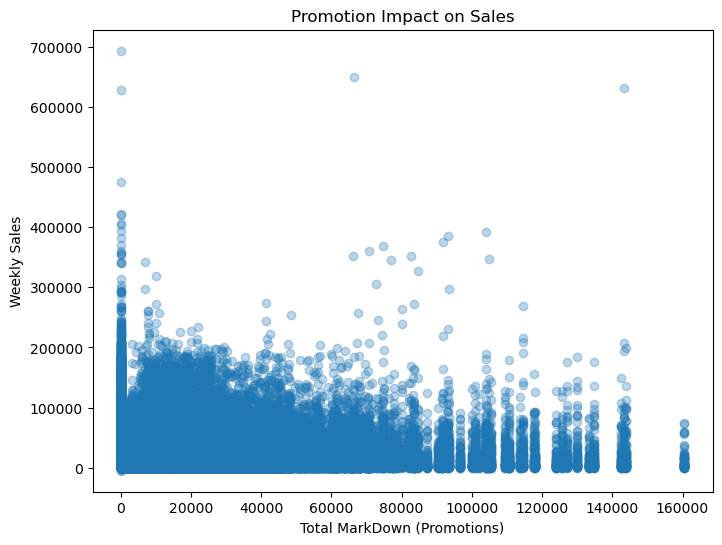

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(df['Total_MarkDown'], df['Weekly_Sales'], alpha=0.3)

plt.title("Promotion Impact on Sales")
plt.xlabel("Total MarkDown (Promotions)")
plt.ylabel("Weekly Sales")

plt.show()

In [50]:
train_data = sales_data[:-20]
test_data = sales_data[-20:]

In [51]:
print("Training data size:", len(train_data))
print("Testing data size:", len(test_data))

Training data size: 123
Testing data size: 20


In [53]:
forecast = model_fit.forecast(steps=len(test_data))

forecast = pd.Series(forecast, index=test_data.index)

forecast.head()

Date
2012-06-15    4.849137e+07
2012-06-22    4.796127e+07
2012-06-29    4.771898e+07
2012-07-06    4.760824e+07
2012-07-13    4.755762e+07
Name: predicted_mean, dtype: float64

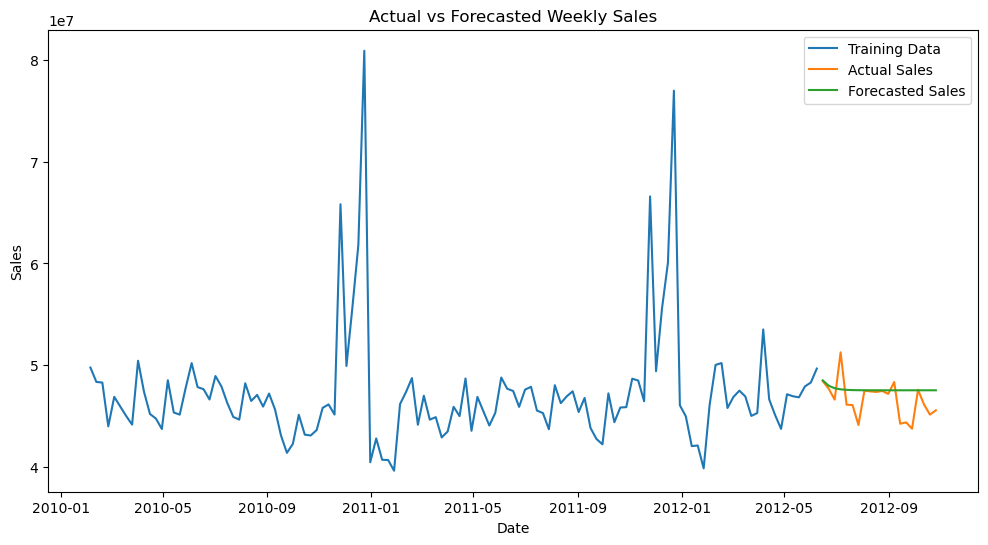

In [54]:
plt.figure(figsize=(12,6))

plt.plot(train_data, label="Training Data")
plt.plot(test_data, label="Actual Sales")
plt.plot(forecast, label="Forecasted Sales")

plt.title("Actual vs Forecasted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test_data, forecast)
rmse = np.sqrt(mean_squared_error(test_data, forecast))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 1453816.4700740487
Root Mean Squared Error (RMSE): 1976658.160503757
